In [9]:
import pandas as pd
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

df = pd.read_csv('../data/Walmart.csv')
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106


In [10]:
#converting to percent change to control for store size
df = df.sort_values(['Store', 'Date'])
df['Sales_Pct_Change'] = df.groupby('Store')['Weekly_Sales'].pct_change()

#defining month as seasonality in addition to Holiday_Flag binary variable
df['Month'] = df['Date'].dt.month

In [11]:
#OLS regression
results = {} #storing each store's regression coefficient

for store_id in df['Store'].unique(): #looping through each unique store
    store_df = df[df['Store'] == store_id].dropna(subset=['Sales_Pct_Change']) #filtering for the store's rows and dropping first week due to lack of Sales_Pct_Change
    model = smf.ols( #fitting Ordinary Least Squares Regression for the store
        'Sales_Pct_Change ~ CPI + Unemployment + Fuel_Price + Holiday_Flag + C(Month)', #predict Sales_Pct_Change using CPI, unemployment, fuel_price and control for month and holidays
        data=store_df
    ).fit()
    results[store_id] = model.params #save the coefficients for the store 

sensitivity_df = pd.DataFrame(results).T #convert results into a DF and transposing for rows
sensitivity_df.head()

,Intercept,C(Month)[T.2],C(Month)[T.3],C(Month)[T.4],C(Month)[T.5],C(Month)[T.6],C(Month)[T.7],C(Month)[T.8],C(Month)[T.9],C(Month)[T.10],C(Month)[T.11],C(Month)[T.12],CPI,Unemployment,Fuel_Price,Holiday_Flag
1,0.391483,0.042438,0.033052,0.009671,0.027087,0.018585,0.010288,0.040951,0.009055,0.030343,0.126891,-0.006322,-0.001423,-0.015693,0.004654,-0.015363
2,1.287557,0.041699,0.018517,0.020673,0.039582,0.022360,0.005644,0.037299,0.006496,0.031954,0.143078,0.006259,-0.005002,-0.033646,0.008106,-0.026785
3,-0.233364,0.041164,0.012312,0.027172,0.030142,0.033225,0.011163,0.040800,0.019007,0.033772,0.153719,-0.028400,0.000826,0.005206,-0.003264,0.007776
4,3.715588,0.054434,0.015993,0.022557,0.029014,0.015685,-0.001022,0.008898,0.013096,0.022014,0.117498,-0.009350,-0.027518,-0.035888,0.008144,-0.040313
5,-0.794654,0.011399,0.036552,0.045911,0.039856,0.025716,0.011572,0.055600,0.005818,0.028874,0.181911,-0.050770,0.003101,0.023484,-0.016419,0.058599


In [12]:
#checking across 45 stores
sensitivity_df.describe()

,Intercept,C(Month)[T.2],C(Month)[T.3],C(Month)[T.4],C(Month)[T.5],C(Month)[T.6],C(Month)[T.7],C(Month)[T.8],C(Month)[T.9],C(Month)[T.10],C(Month)[T.11],C(Month)[T.12],CPI,Unemployment,Fuel_Price,Holiday_Flag
count,45.000000,45.000000,45.000000,45.000000,45.000000,45.000000,45.000000,45.000000,45.000000,45.000000,45.000000,45.000000,45.000000,45.000000,45.000000,45.000000
mean,1.017753,0.033823,0.022227,0.020973,0.040755,0.019264,0.008342,0.033285,0.001321,0.029915,0.129314,-0.017601,-0.005520,-0.031723,-0.004083,0.003253
std,1.799785,0.038563,0.035793,0.032022,0.047014,0.042268,0.036614,0.042405,0.028037,0.040556,0.082534,0.041858,0.011998,0.046262,0.022276,0.049975
min,-2.252494,-0.089927,-0.061636,-0.053185,-0.055457,-0.070575,-0.087208,-0.080594,-0.063882,-0.068475,-0.036364,-0.143536,-0.032995,-0.222428,-0.070882,-0.085813
25%,-0.022182,0.016743,-0.002022,0.009671,0.022196,0.004660,-0.007388,0.008898,-0.014077,0.018650,0.119058,-0.035391,-0.008001,-0.051031,-0.013939,-0.026785
50%,0.391483,0.041164,0.024921,0.027172,0.039856,0.019662,0.011572,0.042486,0.004842,0.036945,0.143078,-0.015196,-0.001225,-0.022302,-0.001899,-0.008863
75%,1.952430,0.057133,0.044183,0.038182,0.063651,0.037233,0.025454,0.056558,0.013096,0.055891,0.178593,-0.002272,0.000826,0.000262,0.007570,0.026111
max,5.359146,0.098973,0.095183,0.098721,0.148169,0.159134,0.099263,0.104228,0.075517,0.095279,0.289240,0.113288,0.018205,0.023484,0.036569,0.146543


In [13]:
cluster_features = sensitivity_df[['CPI', 'Unemployment', 'Fuel_Price']]
scaler = StandardScaler()
scaled_features = scaler.fit_transform(cluster_features) #standardize to avoid dominance due to scale

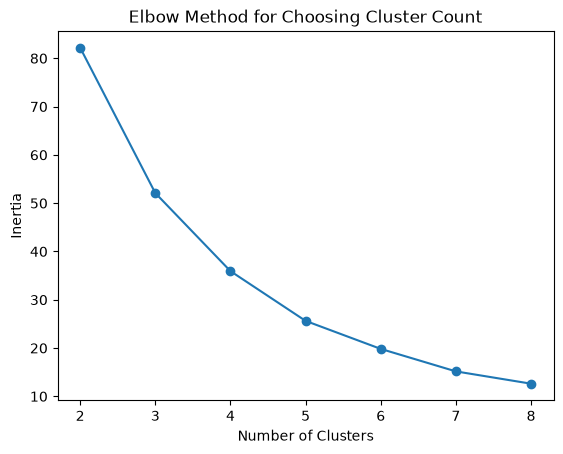

In [ ]:
#Clustering counts 2-8 and tracking fit
inertias = []
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(scaled_features)
    inertias.append(km.inertia_)

plt.plot(range(2, 9), inertias, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method for Choosing Cluster Count')
plt.show()

In [15]:
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10) #fitting final k-means model with k = 4
sensitivity_df['Cluster'] = kmeans_final.fit_predict(scaled_features) #assign each store to a cluster
cluster_profile = sensitivity_df.groupby('Cluster')[['CPI', 'Unemployment', 'Fuel_Price']].mean() #average CPI/unemployment/Fuel_Price sensitivity per cluster
cluster_profile

,CPI,Unemployment,Fuel_Price
Cluster,,,
0,-0.001427,-0.009460,0.000243
1,-0.029239,-0.193784,-0.046656
2,0.004581,-0.033713,-0.030160
3,-0.021721,-0.055560,0.019441


In [16]:
print(sensitivity_df['Cluster'].value_counts()) #counting number of stores in each cluster
tier_names = { #naming each cluster by risk coefficient
    0: 'Stable',
    1: 'High-Risk',
    2: 'Resilient',
    3: 'Moderately Exposed'
}
sensitivity_df['Risk_Tier'] = sensitivity_df['Cluster'].map(tier_names) #mapping tier names to numeric cluster
sensitivity_df[['Cluster', 'Risk_Tier']].head(10)

Cluster
0    25
3     9
2     9
1     2
Name: count, dtype: int64


,Cluster,Risk_Tier
1,0,Stable
2,0,Stable
3,0,Stable
4,3,Moderately Exposed
5,0,Stable
6,0,Stable
7,0,Stable
8,0,Stable
9,0,Stable
10,3,Moderately Exposed


In [ ]:
sensitivity_df[sensitivity_df['Risk_Tier'] == 'High-Risk']

,CPI,Unemployment,Fuel_Price
26,-0.025483,-0.222428,-0.070882
40,-0.032995,-0.165141,-0.022430


In [ ]:
store_avg = df.groupby('Store')['Weekly_Sales'].mean()

# Look up these two stores' average weekly sales
store_avg[[26, 40]]

Store
26    1.002912e+06
40    9.641280e+05
Name: Weekly_Sales, dtype: float64